# 6.3 히스토그램

## 6.3.1 히스토그램 개념

히스토그램이란 어떤 데이터들이 얼마나 많은지를 도수(빈도수) 분포표를 그래프로 그린 것이다.
이는 화소의 분포를 나타내는 지표이므로 분포를 알면 영상의 특성을 판단할 도구가 될 수 있다.

## 6.3.2 히스토그램 게산
화소 값을 화소값이 가질 수 있는 범위에 대하여 빈도 수를 저장하면 된다. 그리고 이를 막대 그래프로 그린다.

In [1]:
import numpy as np, cv2
import matplotlib.pyplot as plt

In [3]:
def calc_histo(image, histSize, ranges=[0,256]):
    hist = np.zeros((histSize, 1), np.float32)
    gap = ranges[1] / histSize

    for row in image:
        for pix in row:
            idx = int(pix / gap)
            hist[idx] += 1

    return hist

## 6.3.3 OpenCV 함수 활용
calcHist() 함수를 이용하면 다채녈의 행렬에서도 다차원의 히스토그램을 구할 수 있다.
https://docs.opencv.org/3.4/d6/dc7/group__imgproc__hist.html 

In [8]:
image = cv2.imread("../images/door.jpg", cv2.IMREAD_GRAYSCALE)

histSize, ranges = [32], [0, 256]
gap = ranges[1] / histSize[0]
ranges_gap = np.arange(0, ranges[1] + 1, gap)
hist1 = calc_histo(image, histSize[0], ranges)
hist2 = cv2.calcHist([image], [0], None, histSize, ranges)
hist3, bins = np.histogram(image, ranges_gap)

print("User Func: ", hist1.flatten())
print("OpenCV Func: ", hist2.flatten())
print("numpy Func: ", hist3)

User Func:  [2.225200e+05 2.574840e+05 3.275370e+05 4.030800e+05 4.382150e+05
 4.064650e+05 3.772810e+05 5.260470e+05 8.442540e+05 7.842640e+05
 6.725010e+05 6.434450e+05 1.099683e+06 1.358913e+06 1.156761e+06
 9.675410e+05 8.386550e+05 8.991630e+05 9.638250e+05 9.826210e+05
 9.558970e+05 9.034380e+05 8.420320e+05 8.722470e+05 1.078317e+06
 9.696940e+05 7.423370e+05 6.679800e+05 9.304240e+05 1.727873e+06
 4.550640e+05 1.546500e+05]
OpenCV Func:  [2.225200e+05 2.574840e+05 3.275370e+05 4.030800e+05 4.382150e+05
 4.064650e+05 3.772810e+05 5.260470e+05 8.442540e+05 7.842640e+05
 6.725010e+05 6.434450e+05 1.099683e+06 1.358913e+06 1.156761e+06
 9.675410e+05 8.386550e+05 8.991630e+05 9.638250e+05 9.826210e+05
 9.558970e+05 9.034380e+05 8.420320e+05 8.722470e+05 1.078317e+06
 9.696940e+05 7.423370e+05 6.679800e+05 9.304240e+05 1.727873e+06
 4.550640e+05 1.546500e+05]
numpy Func:  [ 222520  257484  327537  403080  438215  406465  377281  526047  844254
  784264  672501  643445 1099683 1358913

In [25]:
def draw_histo(hist, shape=(200, 256)):
    hist_img = np.full(shape, 255, np.uint8)
    cv2.normalize(hist, hist, 0, shape[0], cv2.NORM_MINMAX)
    gap = hist_img.shape[1] / hist_img.shape[0]
    hist = hist.flatten()

    for i, h in enumerate(hist):
        x = int(round(i * gap))
        w = int(round(gap))
        cv2.rectangle(hist_img, (x, 0, w, int(h)), 0, cv2.FILLED)
    
    return cv2.flip(hist_img, 0)

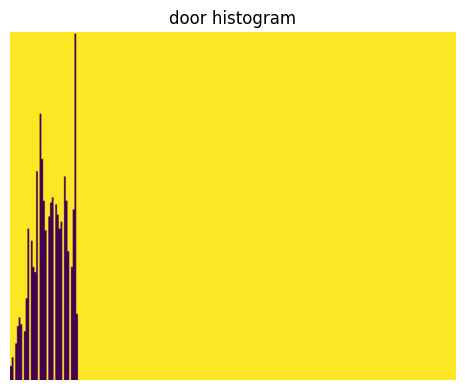

In [39]:
img = cv2.imread("../images/timetable.jpg", cv2.IMREAD_GRAYSCALE)

hist = cv2.calcHist([image], [0], None, [32], [0, 256])
hist_img = draw_histo(hist)

fig = plt.figure(num = 1, figsize=(8, 4))
plt.imshow(hist_img)
plt.title("door histogram")
plt.axis('off')
plt.tight_layout()